In [ ]:
# Core imports for the whole lab
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
print('Setup complete. pandas', pd.__version__)

Setup complete. pandas 2.2.2


In [ ]:
# -----------------------------------------------------------
# A SMALL, ALREADY-CLEAN DATASET (Part 1 did the cleaning)
# -----------------------------------------------------------
# Mixed columns: an unordered category (city), an ordered category
# (size), two numeric features on very different scales, and a target.
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],   # target
})
df

,city,size,age,income,bought
0,pune,small,25,38000,0
1,delhi,large,41,92000,1
2,mumbai,medium,33,55000,0
3,pune,medium,29,47000,0
4,delhi,small,52,120000,1
5,mumbai,large,38,76000,1
6,pune,large,46,88000,1
7,delhi,small,22,41000,0


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. ONE-HOT ENCODING (for UNORDERED categories)
# -----------------------------------------------------------

# 'city' has no natural order -> one 0/1 column per category
city_ohe = pd.get_dummies(df['city'], prefix='city').astype(int)
city_ohe

,city_delhi,city_mumbai,city_pune
0,0,0,1
1,1,0,0
2,0,1,0
3,0,0,1
4,1,0,0
5,0,1,0
6,0,0,1
7,1,0,0


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. LABEL / ORDINAL ENCODING (for ORDERED categories)
# -----------------------------------------------------------

# 'size' has a real order: small < medium < large -> map to 0,1,2
size_order = {'small': 0, 'medium': 1, 'large': 2}
df['size_code'] = df['size'].map(size_order)
df[['size', 'size_code']]


,size,size_code
0,small,0
1,large,2
2,medium,1
3,medium,1
4,small,0
5,large,2
6,large,2
7,small,0


In [ ]:
# Re-initialize df to ensure consistent starting state for transformations
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],   # target
})

# 1. one-hot encode just the 'city' column of the whole df
# YOUR CODE HERE
df_one_hot_city = pd.get_dummies(df['city'], prefix='city', drop_first=True, dtype=int)
print("One-hot encoded 'city' column:")
display(df_one_hot_city)

# 2. ordinal-encode 'size' (map with size_order)
# YOUR CODE HERE
size_order = {'small': 0, 'medium': 1, 'large': 2}
df['size_code'] = df['size'].map(size_order)
print("\nOrdinal encoded 'size' column:")
display(df[['size', 'size_code']])

# 3. Why one-hot is wrong for size / ordinal is wrong for city:   (comment)
# One-hot is wrong for size because it ignores the inherent order, while ordinal is wrong for city because it imposes a false order.

One-hot encoded 'city' column:


,city_mumbai,city_pune
0,0,1
1,0,0
2,1,0
3,0,1
4,0,0
5,1,0
6,0,1
7,0,0



Ordinal encoded 'size' column:


,size,size_code
0,small,0
1,large,2
2,medium,1
3,medium,1
4,small,0
5,large,2
6,large,2
7,small,0


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. THE PROBLEM — FEATURES ON DIFFERENT SCALES
# -----------------------------------------------------------

# income (tens of thousands) dwarfs age (tens). A distance-based
# model would treat income as nearly all that matters.
print(df[['age', 'income']].describe().loc[['min', 'max', 'mean']])

        age    income
min   22.00   38000.0
max   52.00  120000.0
mean  35.75   69625.0


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. STANDARDISATION (Z-score)  vs  NORMALISATION (Min-Max)
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler, MinMaxScaler

num = df[['age', 'income']]

z = StandardScaler().fit_transform(num)        # mean 0, std 1
m = MinMaxScaler().fit_transform(num)          # range [0, 1]

print('Standardised (mean~0, std~1):')
print(pd.DataFrame(z, columns=['age', 'income']).round(2).head(3))
print('\nMin-Max (range 0..1):')
print(pd.DataFrame(m, columns=['age', 'income']).round(2).head(3))

Standardised (mean~0, std~1):
    age  income
0 -1.10   -1.16
1  0.54    0.82
2 -0.28   -0.54

Min-Max (range 0..1):
    age  income
0  0.10    0.00
1  0.63    0.66
2  0.37    0.21


In [ ]:
income = df[['income']]   # 2D shape for sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. standardise -> check mean ~0, std ~1
standard_scaler = StandardScaler()
income_standardized = standard_scaler.fit_transform(income)
print('Standardised Income (mean ~0, std ~1):')
display(pd.DataFrame(income_standardized, columns=['income']).round(2).head(3))
# Verify mean and std
# print(f'Mean: {income_standardized.mean():.2f}, Std Dev: {income_standardized.std():.2f}')

# 2. min-max scale -> check min 0, max 1
min_max_scaler = MinMaxScaler()
income_min_max_scaled = min_max_scaler.fit_transform(income)
print('\nMin-Max Scaled Income (min 0, max 1):')
display(pd.DataFrame(income_min_max_scaled, columns=['income']).round(2).head(3))
# Verify min and max
# print(f'Min: {income_min_max_scaled.min():.2f}, Max: {income_min_max_scaled.max():.2f}')

# 3. Needs scaling: 'age', 'income' (numerical features with different scales). Doesn't need it: 'bought' (binary target), 'city' (one-hot encoded), 'size' (ordinal encoded with meaningful numeric mapping).   (comment)

Standardised Income (mean ~0, std ~1):


,income
0,-1.16
1,0.82
2,-0.54



Min-Max Scaled Income (min 0, max 1):


,income
0,0.00
1,0.66
2,0.21


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. SPLIT FIRST, THEN FIT ON TRAIN ONLY
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['age', 'income']]
y = df['bought']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # FIT + transform on train
X_test_s  = scaler.transform(X_test)        # only TRANSFORM on test
print('train rows:', X_train.shape[0], '| test rows:', X_test.shape[0])
print('scaler learned mean from TRAIN only:', scaler.mean_.round(1))

train rows: 6 | test rows: 2
scaler learned mean from TRAIN only: [3.45e+01 6.90e+04]


In [ ]:
# 1a. WRONG: fit on ALL data, then split (leakage!)
wrong_mean = StandardScaler().fit(X).mean_

# 1b. RIGHT: fit on TRAIN only
right_mean = StandardScaler().fit(X_train).mean_

print('fit-on-all mean :', wrong_mean.round(1))
print('fit-on-train mean:', right_mean.round(1))

# 2. Why fitting on all data is a problem: ...   (write your answer)

fit-on-all mean : [3.5800e+01 6.9625e+04]
fit-on-train mean: [3.45e+01 6.90e+04]


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. COMBINE & BIN EXISTING COLUMNS
# -----------------------------------------------------------

fe = df.copy()
# combine: income per year of age (a crude 'earning rate')
fe['income_per_age'] = (fe['income'] / fe['age']).round(0)
# bin: turn continuous age into life-stage buckets
fe['age_group'] = pd.cut(fe['age'], bins=[0, 30, 45, 100],
                         labels=['young', 'mid', 'senior'])
fe[['age', 'income', 'income_per_age', 'age_group']]

,age,income,income_per_age,age_group
0,25,38000,1520.0,young
1,41,92000,2244.0,mid
2,33,55000,1667.0,mid
3,29,47000,1621.0,young
4,52,120000,2308.0,senior
5,38,76000,2000.0,mid
6,46,88000,1913.0,senior
7,22,41000,1864.0,young


In [ ]:
# -----------------------------------------------------------
# 🔹 4B. EXTRACT FROM A DATE
# -----------------------------------------------------------

dates = pd.to_datetime(['2024-01-06', '2024-03-15', '2024-07-21', '2024-12-25'])
d = pd.DataFrame({'date': dates})
d['day_of_week'] = d['date'].dt.day_name()   # Monday, Tuesday, ...
d['month']       = d['date'].dt.month
d['is_weekend']  = d['date'].dt.dayofweek >= 5
d

,date,day_of_week,month,is_weekend
0,2024-01-06,Saturday,1,True
1,2024-03-15,Friday,3,False
2,2024-07-21,Sunday,7,True
3,2024-12-25,Wednesday,12,False


In [ ]:
ex = df.copy()

# 1. high_earner flag (income > median)
# YOUR CODE HERE
median_income = ex['income'].median()
ex['high_earner'] = ex['income'] > median_income
# 2. bin income into 3 buckets with pd.cut
# YOUR CODE HERE
ex['income_bucket'] = pd.cut(ex['income'], bins=3,labels=['Low', 'Medium', 'High'])
# 3. show income + the new columns
# YOUR CODE HERE
ex[['income', 'high_earner', 'income_bucket']]

,income,high_earner,income_bucket
0,38000,False,Low
1,92000,True,Medium
2,55000,False,Low
3,47000,False,Low
4,120000,True,High
5,76000,True,Medium
6,88000,True,Medium
7,41000,False,Low


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. ONE LEAK-FREE PIPELINE: PREPROCESS + MODEL
# -----------------------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

num_cols = ['age', 'income']
cat_cols = ['city', 'size']

# scale the numbers, one-hot the categories — all in one object
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])
pipe = Pipeline([('prep', pre), ('model', LogisticRegression(max_iter=1000))])
print(pipe)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'income']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city', 'size'])])),
                ('model', LogisticRegression(max_iter=1000))])


In [ ]:
# -----------------------------------------------------------
# 🔹 5B. FIT THE WHOLE THING IN ONE CALL
# -----------------------------------------------------------

X = df[num_cols + cat_cols]
y = df['bought']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

pipe.fit(X_train, y_train)        # preprocessing fitted on TRAIN only — no leakage
acc = pipe.score(X_test, y_test)  # transforms test with train-fitted steps
print('Test accuracy:', round(acc, 2))
print('(small toy dataset — the point is the leak-free workflow, not the score)')

Test accuracy: 1.0
(small toy dataset — the point is the leak-free workflow, not the score)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

Xn = df[['age', 'income']]
yn = df['bought']

# 1. Pipeline: MinMaxScaler -> LogisticRegression
# YOUR CODE HERE
pipe_mm = Pipeline([('scaler', MinMaxScaler()),('model', LogisticRegression(max_iter=1000))])
# 2. split + fit on train
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(Xn, yn, test_size=0.25, random_state=0)
pipe_mm.fit(X_train, y_train)
# 3. print test accuracy
# YOUR CODE HERE
acc = pipe_mm.score(X_test, y_test)
print('Test accuracy:', round(acc, 2))

Test accuracy: 1.0


EDA

In [ ]:
# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='/content/ecommerce_customers.csv',
                   xlsx_path='/content/transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()   # creates the two resource files locally
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Found the provided dataset files.


In [ ]:
# Load the customer table (parse the date columns as real datetimes)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('ecommerce_customers.csv',
                 parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
print('Loaded', df.shape[0], 'customers x', df.shape[1], 'columns')
df.head()

Loaded 2500 customers x 15 columns


,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. STRUCTURE: what are we working with?
# -----------------------------------------------------------
df.info()   # column types + non-null counts


# -----------------------------------------------------------
# 🔹 1B. QUALITY SNAPSHOT: missingness + the target balance
# -----------------------------------------------------------
print('Missing values (%):')
print((df.isna().mean() * 100).round(1).sort_values(ascending=False).head(6))
print('\nChurn rate (target):', round(df['is_churned'].mean(), 3))
print('Customers with zero orders:', int((df['num_orders'] == 0).sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2500 non-null   object        
 1   signup_date       2500 non-null   datetime64[ns]
 2   first_order_date  2131 non-null   datetime64[ns]
 3   last_order_date   2131 non-null   datetime64[ns]
 4   age               2325 non-null   float64       
 5   gender            2400 non-null   object        
 6   city              2450 non-null   object        
 7   plan              2500 non-null   object        
 8   device            2500 non-null   object        
 9   payment_method    2500 non-null   object        
 10  num_orders        2500 non-null   int64         
 11  total_spend       2500 non-null   float64       
 12  support_tickets   2500 non-null   int64         
 13  email_opt_in      2500 non-null   int64         
 14  is_churned        2500 n

In [ ]:
# 1. is customer_id unique?
print('Is customer_id unique?', df['customer_id'].is_unique)

# 2. numeric summary
display(df.describe().round(2))

# 3. Three issues I can see:
# - Missing values: 'first_order_date', 'last_order_date', 'age', 'gender', and 'city' columns have missing values. Specifically, 'first_order_date' and 'last_order_date' are missing for customers with no orders.
# - Data Type Mismatch: 'age' is a float type but likely represents an integer age. It should be converted to an integer after handling missing values.
# - Outliers/Skewness: The 'total_spend' column likely contains outliers or is highly skewed, which can be seen from its descriptive statistics (max value being much higher than 75th percentile) and was also mentioned in the dataset generation function's description. This could affect model performance if not handled.

Is customer_id unique? True


,signup_date,first_order_date,last_order_date,age,num_orders,total_spend,support_tickets,email_opt_in,is_churned
count,2500,2131,2131,2325.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,2022-08-29 07:45:59.040000,2023-03-07 03:13:56.227123200,2024-01-01 16:56:59.239793664,37.89,3.26,112.27,0.61,0.66,0.17
min,2021-01-01 00:00:00,2021-01-24 00:00:00,2021-03-23 00:00:00,18.00,0.00,0.00,0.00,0.00,0.00
25%,2021-10-30 00:00:00,2022-07-06 12:00:00,2023-10-20 00:00:00,30.00,1.00,25.79,0.00,0.00,0.00
50%,2022-08-24 12:00:00,2023-04-22 00:00:00,2024-03-18 00:00:00,37.00,3.00,79.12,0.00,1.00,0.00
75%,2023-07-01 00:00:00,2023-12-05 00:00:00,2024-05-25 00:00:00,46.00,5.00,161.65,1.00,1.00,0.00
max,2024-04-30 00:00:00,2024-06-28 00:00:00,2024-06-29 00:00:00,82.00,19.00,791.37,5.00,1.00,1.00
std,NaN,NaN,NaN,11.34,2.91,117.21,0.78,0.48,0.37


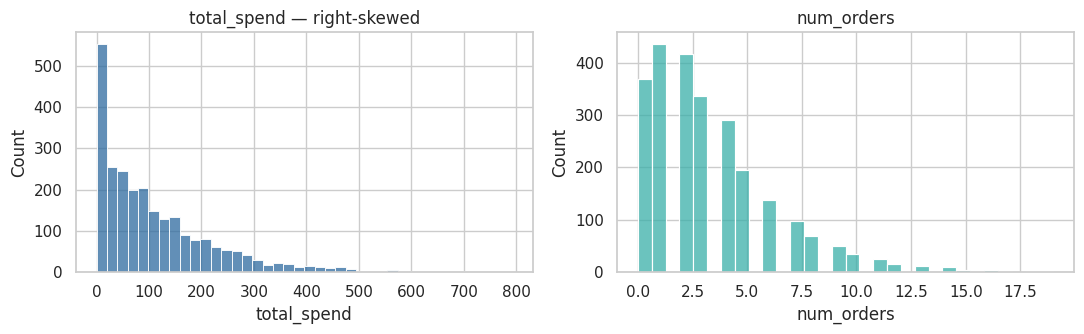

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. DISTRIBUTION OF SPEND  (note the long right tail)
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['total_spend'], bins=40, ax=ax[0], color='#2D6A9F')
ax[0].set_title('total_spend — right-skewed')
sns.histplot(df['num_orders'], bins=30, ax=ax[1], color='#3AAFA9')
ax[1].set_title('num_orders')
plt.tight_layout(); plt.show()


Text(0, 0.5, 'Count')

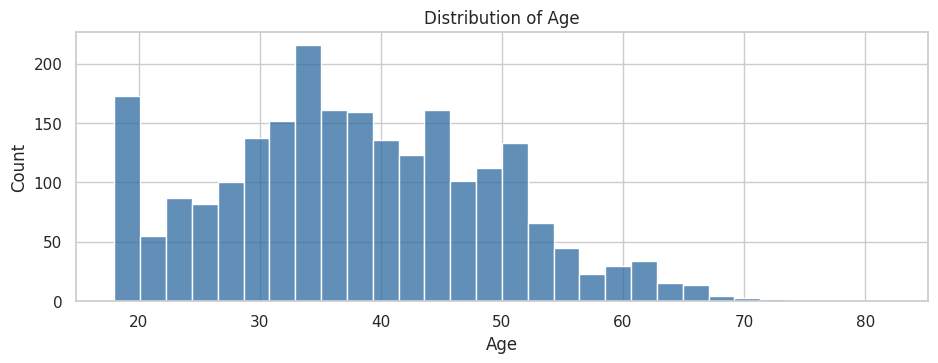

In [ ]:
# 1. histogram of age (drop NaN)
# YOUR CODE HER
fig, ax = plt.subplots(1, 1, figsize=(11,3.5))
sns.histplot(df['age'].dropna(), bins=30, ax=ax, color='#2D6A9F')
ax.set_title('Distribution of Age')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
E

# 2. Shape description: The age distribution appears to be somewhat normally distributed, centered around the 30-40 age range, with a slight right skew or a tail extending towards older ages. This is a common pattern in customer demographics.

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. MEAN vs MEDIAN ON A SKEWED COLUMN
# -----------------------------------------------------------
# When data is right-skewed, the mean is pulled up by big spenders.
spend = df['total_spend']
print('mean  :', round(spend.mean(), 1))
print('median:', round(spend.median(), 1))
print('skew  :', round(spend.skew(), 2), ' (> 0 means right-skewed)')
print('\nThe mean > median gap is the skew talking.')

mean  : 112.3
median: 79.1
skew  : 1.73  (> 0 means right-skewed)

The mean > median gap is the skew talking.


In [ ]:
# 1. skew of the two columns
# YOUR CODE HERE
print(f"Skewness of 'age': {df['age'].skew().round(2)}")
print(f"Skewness of 'total_spend': {df['total_spend'].skew().round(2)}")

# 2 & 3. Which average for each, and why:
# - For 'age': The skewness is relatively close to 0, indicating a fairly symmetrical distribution (as seen in the histogram). Therefore, the **mean** would be an appropriate measure of central tendency as it effectively represents the center of such distributions.
# - For 'total_spend': The skewness is significantly positive (right-skewed), as indicated by the value and the previous histogram. In such cases, the **median** is a more robust and representative measure of the 'average' spend, as it is less affected by the extreme values (outliers or 'whales') in the long tail of the distribution compared to the mean.

Skewness of 'age': 0.23
Skewness of 'total_spend': 1.73


Plan mix:
plan
Basic       0.494
Standard    0.352
Premium     0.154
Name: proportion, dtype: float64

Top cities:
city
Mumbai       416
Delhi        405
Bengaluru    390
Hyderabad    320
Chennai      253
Name: count, dtype: int64


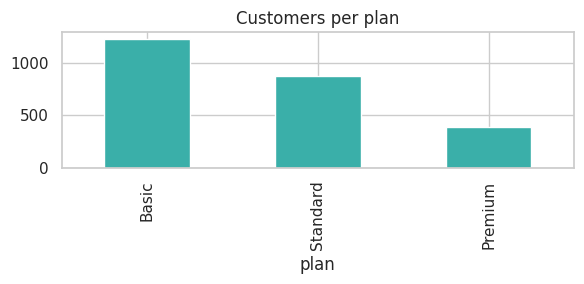

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. CATEGORY FREQUENCIES
# -----------------------------------------------------------
print('Plan mix:')
print(df['plan'].value_counts(normalize=True).round(3))
print('\nTop cities:')
print(df['city'].value_counts().head(5))

fig, ax = plt.subplots(figsize=(6, 3))
df['plan'].value_counts().plot(kind='bar', ax=ax, color='#3AAFA9')
ax.set_title('Customers per plan'); plt.tight_layout(); plt.show()


Churn vs Retained Proportions (0=retained, 1=churned):


,proportion
is_churned,
0,0.834
1,0.166



Imbalance ratio (retained / churned): 5.02


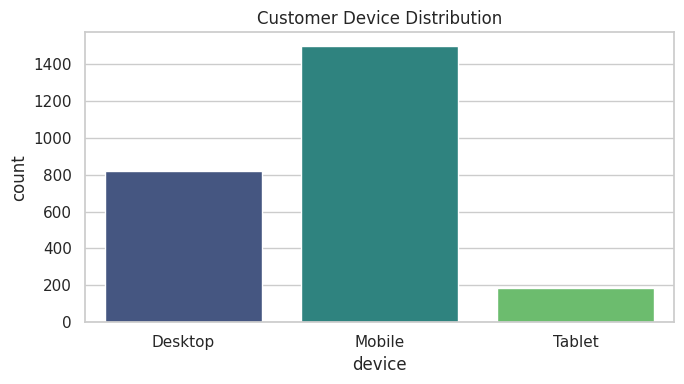

In [ ]:
# 1. churn vs retained proportions
# YOUR CODE HERE
churn_proportions = df['is_churned'].value_counts(normalize=True).round(3)
print('Churn vs Retained Proportions (0=retained, 1=churned):')
display(churn_proportions)

# 2. imbalance ratio (retained / churned)
# YOUR CODE HERE
retained_count = df['is_churned'].value_counts()[0]
churned_count = df['is_churned'].value_counts()[1]
imbalance_ratio = round(retained_count / churned_count, 2)
print(f'\nImbalance ratio (retained / churned): {imbalance_ratio}')

# 3. bar chart of device + comment on the dominant category
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(x='device', data=df, ax=ax, palette='viridis', hue='device', legend=False)
ax.set_title('Customer Device Distribution')
plt.tight_layout()
plt.show()

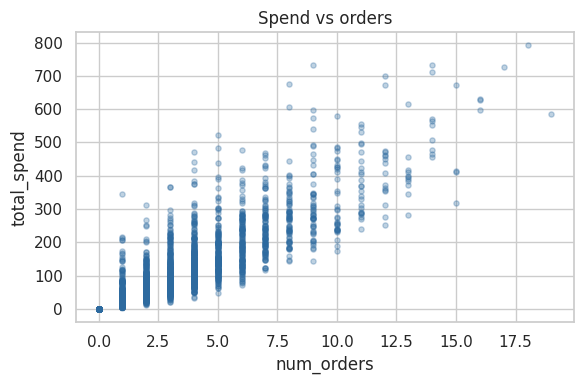

correlation: 0.864


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. DO SPEND AND ORDER COUNT MOVE TOGETHER?
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['num_orders'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('num_orders'); ax.set_ylabel('total_spend')
ax.set_title('Spend vs orders'); plt.tight_layout(); plt.show()

print('correlation:', round(df['num_orders'].corr(df['total_spend']), 3))

In [ ]:
# 1. scatter age vs total_spend
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['age'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('Age')
ax.set_ylabel('Total Spend')
ax.set_title('Age vs Total Spend')
plt.tight_layout(); plt.show()

# 2. correlation
# YOUR CODE HERE
correlation_age_spend = df['age'].corr(df['total_spend'])
print(f"Correlation between 'age' and 'total_spend': {correlation_age_spend:.3f}")

# 3. Interpretation: The scatter plot and the correlation coefficient indicate a very weak positive relationship between age and total spend. This suggests that as age increases, total spend tends to slightly increase, but the relationship is not strong or linear, and many other factors likely influence total spend.

            num_orders  total_spend  support_tickets
is_churned                                          
0                  3.6        125.5              0.6
1                  1.4         45.9              0.7


/tmp/ipykernel_590/3518072038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,


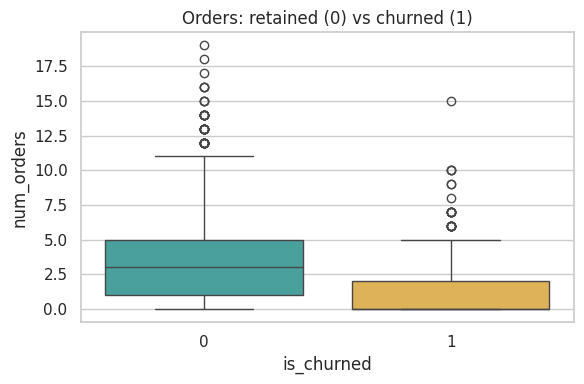

In [ ]:
# -----------------------------------------------------------
# 🔹 6A. HOW DO CHURNERS DIFFER?  (group means)
# -----------------------------------------------------------
cols = ['num_orders', 'total_spend', 'support_tickets']
print(df.groupby('is_churned')[cols].mean().round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,
            palette=['#3AAFA9', '#F4B942'])
ax.set_title('Orders: retained (0) vs churned (1)')
plt.tight_layout(); plt.show()

Mean support tickets by churn status (0=retained, 1=churned):


,support_tickets
is_churned,
0,0.59
1,0.73


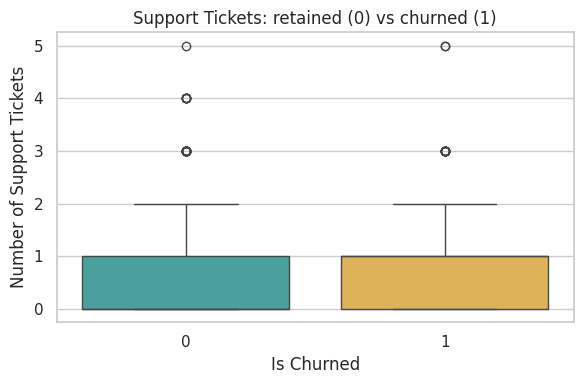

In [ ]:
# 1. mean support_tickets by churn
# YOUR CODE HERE
mean_support_tickets_by_churn = df.groupby('is_churned')['support_tickets'].mean().round(2)
print('Mean support tickets by churn status (0=retained, 1=churned):')
display(mean_support_tickets_by_churn)

# 2. box plot of support_tickets by is_churned
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='is_churned', y='support_tickets', ax=ax,
            palette=['#3AAFA9', '#F4B942'], hue='is_churned', legend=False)
ax.set_title('Support Tickets: retained (0) vs churned (1)')
ax.set_xlabel('Is Churned')
ax.set_ylabel('Number of Support Tickets')
plt.tight_layout(); plt.show()

# 3. Is it a warning sign?
# Yes, higher support tickets appear to be a warning sign for churn. The mean number of support tickets is higher for churned customers (0.7) compared to retained customers (0.6). The box plot further illustrates this, showing that churned customers (is_churned=1) generally have a slightly higher median and more outliers in terms of support tickets, suggesting they might be experiencing more issues leading to churn.

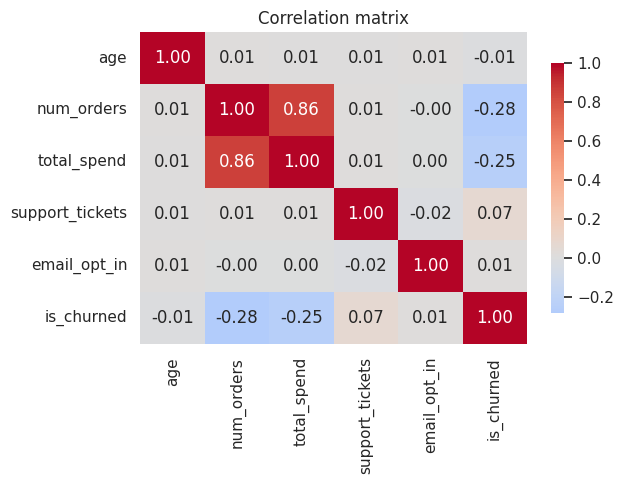

Correlation with churn (sorted):
num_orders        -0.282144
total_spend       -0.252546
age               -0.010746
email_opt_in       0.011145
support_tickets    0.068880
Name: is_churned, dtype: float64


In [ ]:
# -----------------------------------------------------------
# 🔹 7A. WHAT CORRELATES WITH CHURN?
# -----------------------------------------------------------
num = ['age', 'num_orders', 'total_spend', 'support_tickets',
       'email_opt_in', 'is_churned']
corr = df[num].corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Correlation matrix'); plt.tight_layout(); plt.show()

print('Correlation with churn (sorted):')
print(corr['is_churned'].drop('is_churned').sort_values())

In [ ]:
# 1. top-2 absolute correlations with churn
#    hint: corr['is_churned'].drop('is_churned').abs().sort_values(ascending=False).head(2)
# YOUR CODE HERE
print('Top 2 absolute correlations with churn:')
top_2_corr = corr['is_churned'].drop('is_churned').abs().sort_values(ascending=False).head(2)
display(top_2_corr)

# 2. Direction of each driver:
# - num_orders: Has a negative correlation (-0.28). This suggests that customers with a higher number of orders are less likely to churn.
# - total_spend: Also has a negative correlation (-0.25). This indicates that customers who spend more are less likely to churn.

In [ ]:
# -----------------------------------------------------------
# 🔹 8A. CHURN RATE BY SEGMENT
# -----------------------------------------------------------
print('Churn rate by plan:')
print(df.groupby('plan')['is_churned'].mean().round(3).sort_values(ascending=False))

print('\nChurn rate by device x plan:')
print(df.pivot_table(values='is_churned', index='plan',
                     columns='device', aggfunc='mean').round(3))


In [ ]:
# 1. churn rate by payment_method
# YOUR CODE HERE
print('Churn rate by payment method:')
display(df.groupby('payment_method')['is_churned'].mean().round(3).sort_values(ascending=False))

# 2. pivot: churn rate by plan x email_opt_in
# YOUR CODE HERE
print('\nChurn rate by plan x email_opt_in:')
display(df.pivot_table(values='is_churned', index='plan',
                     columns='email_opt_in', aggfunc='mean').round(3))

# 3. Worst-churning segment:
# Based on the pivot table, the worst-churning segment appears to be 'Basic' plan customers who have not opted into email ('email_opt_in': 0), with a churn rate of 0.222.

Churn rate by payment method:


,is_churned
payment_method,
Card,0.175
UPI,0.169
NetBanking,0.151
Wallet,0.143



Churn rate by plan x email_opt_in:


email_opt_in,0,1
plan,,
Basic,0.157,0.166
Premium,0.170,0.151
Standard,0.160,0.181


In [ ]:
# -----------------------------------------------------------
# 🔹 9A. OUTLIERS IN SPEND (IQR rule)
# -----------------------------------------------------------
q1, q3 = df['total_spend'].quantile([0.25, 0.75])
iqr = q3 - q1
high = q3 + 1.5 * iqr
outliers = df[df['total_spend'] > high]
print(f'IQR upper bound: {high:.0f}')
print('Whale customers above it:', len(outliers))
print(outliers[['customer_id', 'num_orders', 'total_spend']]
      .sort_values('total_spend', ascending=False).head())

IQR upper bound: 365
Whale customers above it: 110
     customer_id  num_orders  total_spend
812    CUST00813          18       791.37
1176   CUST01177          14       732.79
875    CUST00876           9       732.24
562    CUST00563          17       727.37
768    CUST00769          14       710.47


In [ ]:
# 1. skew of total_spend
# YOUR CODE HERE
print(f"Skewness of 'total_spend': {df['total_spend'].skew().round(2)}")

# 2. churn rate (rare-class share)
# YOUR CODE HERE
churn_rate = df['is_churned'].mean().round(3)
print(f"Churn rate (rare-class share): {churn_rate}")

# 3. column with the most missing values
# YOUR CODE HERE
missing_values = df.isnull().sum().sort_values(ascending=False)
most_missing_column = missing_values.index[0]
print(f"Column with the most missing values: '{most_missing_column}' ({missing_values.iloc[0]} missing values)")

# 4. One fix per flag: skew -> ... ; imbalance -> ... ; missing -> ...   (comment)
# - Skew: For 'total_spend', a common fix is to apply a logarithmic transformation (e.g., np.log1p) to reduce the skewness, making the distribution more symmetrical and suitable for models that assume normality.
# - Imbalance: For the 'is_churned' target, oversampling the minority class (churned customers) using techniques like SMOTE or undersampling the majority class (retained customers) can help address the class imbalance during model training.
# - Missing: For 'first_order_date' (or any column with many missing values), strategies include imputation (e.g., filling with a default value like the signup date or a specific placeholder for 'no order'), or in some cases, if the missingness is extensive and non-informative, the column might be dropped or used to create a 'has_order' binary feature.

Skewness of 'total_spend': 1.73
Churn rate (rare-class share): 0.166
Column with the most missing values: 'first_order_date' (369 missing values)
